Cauã Benini da Silva (RA )

Universidade Federal de São Carlos (UFSCar)

# Trabalho de Conclusão de Curso (TCC) - Análise Exploratória


# Introdução

O objetivo deste trabalho é prever casos de hipotensão intradiálica em pacientes renais crônicos e posteriormente, adaptar estes modelos para uma plataforma web a fim de simular sessões de hemodiálise em Real Time.

Este trabalho se baseou no artigo *Predicting the Appearance of Hypotension during Hemodialysis Sessions Using Machine Learning Classifiers* (https://www.mdpi.com/1660-4601/18/5/2364#Abstract).

Abaixo, segue a importação das bibliotecas necessárias para esse desenvolvimento.

In [57]:
# Realizar download do Dataset do Drive
!pip install gdown pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
# bibliotecas necessarias para leitura de dados e visualizacao
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# metricas de desempenho e processamento em geral
from sklearn.preprocessing import MinMaxScaler

# ignora warnings
from warnings import filterwarnings
filterwarnings('ignore')

# Seleção do Dataset

Utilizou-se o dataset [*Dialysis database: sessions with valid data of clinical parameters*](https://data.mendeley.com/datasets/7kmtsmsgfw/1), disponibilizada pelos autores do artigo citado.

Este conjunto de dados foi coletado no Hospital Príncipe de Asturias (Madrid, Espanha) entre os anos de 2016 e 2019, abrangendo informações clínicas de 758 pacientes submetidos a tratamento de hemodiálise.

O dataset contém aproximadamente 98.015 sessões de hemodiálise, cada uma re-gistrada com até 22 parâmetros clínicos medidos em seis momentos distintos da sessão (Horas 0 a 5), além de informações demográficas como idade e sexo dos pacientes. Entre os parâmetros monitorados estão pressão arterial sistólica e diastólica, frequência cardíaca, peso pré e pós-diálise, volume de ultrafiltração, condutividade do banho de hemodiálise, temperatura corporal, entre outros.

A identificação de episódios de hipotensão intradialítica foi realizada a partir da queda da pressão arterial sistólica maior ou igual a 20 mmHg entre os períodos iniciais e intermediários da sessão. Com base nesse critério, cerca de 25.026 sessões (aproximadamente 26% do total) apresentaram episódios de hipotensão, distribuídos entre 584 pacientes (77% da amostra).

In [59]:
import gdown

url = 'https://drive.google.com/file/d/1SSWN2AsJLbA49CdpjlOyQYboRa3mCaiq/view?usp=sharing'
output = 'data/dataset.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1SSWN2AsJLbA49CdpjlOyQYboRa3mCaiq
To: c:\Users\cauab\OneDrive\Área de Trabalho\TCC\data\dataset.csv
100%|██████████| 20.1M/20.1M [00:00<00:00, 27.5MB/s]


'data/dataset.csv'

In [60]:
# Transformar em Dataframe do Pandas e printar
import pandas as pd

df = pd.read_csv('data/dataset.csv', sep=";", index_col=False)
df

,D_Hipotension,D_Sexo,D_Edad,D_Dializador,D_Bano,D_Tecnica,D_PesoSeco,D_PesoPre,D_PesoPost,D_Ganancia,...,D_ConductividadBano,D_ConductividadBicarbonato,D_PresionArterial,D_PresionVenosa,D_PTM,D_TAS,D_TAD,D_Pulso,D_UF,D_Temperatura
0,NO,1,69,10,1,2,0.0,0.0,0.0,0.0,...,13.7,0.0,-125.0,110.0,20.0,130.0,48.0,77.0,0.10,37.2
1,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
2,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
3,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
4,NO,1,69,8,1,1,69.0,70.0,68.6,1.0,...,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97635,NO,1,82,1,15,0,71.0,73.7,71.1,2.8,...,13.7,0.0,-230.0,140.0,25.0,150.0,67.0,70.0,0.74,0.0
97636,NO,1,82,1,15,0,71.0,72.8,71.0,1.7,...,13.7,0.0,-200.0,155.0,15.0,129.0,60.0,83.0,0.51,0.0
97637,SI,1,54,10,7,2,0.0,0.0,0.0,0.0,...,140.0,35.0,0.0,0.0,0.0,155.0,79.0,56.0,0.00,36.0
97638,NO,1,54,8,7,2,0.0,0.0,0.0,0.0,...,14.0,0.0,-125.0,145.0,130.0,143.0,76.0,47.0,0.14,37.1


# Estudo e Preparação

Inicialmente, o conjunto de dados será estudado, de forma a selecionar e pré-processar os atributos, permitindo que estes obtenham os melhores resultados possíveis quando aplicados aos modelos. Primeiramente, é feita uma apresentação inicial do que cada atributo representa e como estão organizados.

Embora o próprio artigo base forneça um estudo completo sobre os dados, entende-se que é necessário realizar uma análise exploratória destes dados, pois o Datasetet fornecido já está pré-processado (exemplo: sem os IDs dos pacientes, com os atributos categóricos já em formato numérico). Desta forma, o estudo se faz necessário não só para compreensão dos dados, mas também para validação das informações expostas no artigo.

Os dados são organizados em 45 atributos, havendo um total de 97640 tuplas.

In [61]:
df.shape

(97640, 25)

Para facilitar o entendimento, aplicou-se os mesmo nomes das colunas encontrados no artigo base neste dataset (já estavam na mesma ordem, apenas foram traduzidas para Espannhol).

Segue a tabela que mostra a descrição de cada um dos atributos:

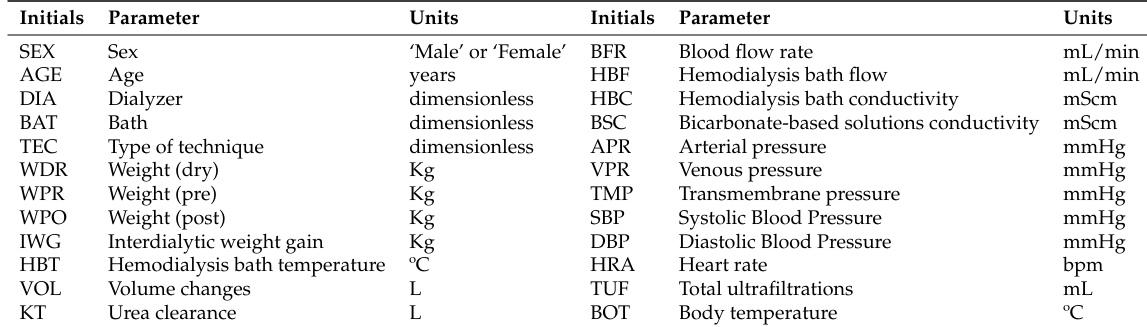


In [62]:
df.columns = ["Hypotension","SEX","AGE","DIA","BAT","TEC","WDR","WPR","WPO","IWG",
              "HBT","VOL","KT","BFR","HBF","HBC","BSC","APR","VPR","TMP",
              "SBP","DBP","HRA","TUF","BOT"]
df

,Hypotension,SEX,AGE,DIA,BAT,TEC,WDR,WPR,WPO,IWG,...,HBC,BSC,APR,VPR,TMP,SBP,DBP,HRA,TUF,BOT
0,NO,1,69,10,1,2,0.0,0.0,0.0,0.0,...,13.7,0.0,-125.0,110.0,20.0,130.0,48.0,77.0,0.10,37.2
1,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
2,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
3,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
4,NO,1,69,8,1,1,69.0,70.0,68.6,1.0,...,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97635,NO,1,82,1,15,0,71.0,73.7,71.1,2.8,...,13.7,0.0,-230.0,140.0,25.0,150.0,67.0,70.0,0.74,0.0
97636,NO,1,82,1,15,0,71.0,72.8,71.0,1.7,...,13.7,0.0,-200.0,155.0,15.0,129.0,60.0,83.0,0.51,0.0
97637,SI,1,54,10,7,2,0.0,0.0,0.0,0.0,...,140.0,35.0,0.0,0.0,0.0,155.0,79.0,56.0,0.00,36.0
97638,NO,1,54,8,7,2,0.0,0.0,0.0,0.0,...,14.0,0.0,-125.0,145.0,130.0,143.0,76.0,47.0,0.14,37.1


Faz-se necessária uma exploração inicial e pré-processamento dos dos dados, para garantir a qualidade deles e posterior eficiência dos modelos aplicados. Assim, aplica-se os seguintes passos:

1. Visualização dos dados
2. Seleção de atributos
3. Tratamento de tuplas vazias e duplicadas
4. Tratamento e seleção de atributos nominais
5. Tratamento de atributos numéricos
6. Amostragem

## 1. Visualização dos dados

Nesta primeira etapa, será feita a exploração inicial dos dados a partir de métodos visuais, de forma e gerar uma compreensão inicial acerca deles, permitindo que decisões plausíveis sejam tomadas nas etapas seguintes, baseando-se na semântica do conjunto

In [63]:
df.dtypes

Hypotension        str
SEX              int64
AGE              int64
DIA              int64
BAT              int64
TEC              int64
WDR            float64
WPR            float64
WPO            float64
IWG            float64
HBT            float64
VOL            float64
KT             float64
BFR            float64
HBF            float64
HBC            float64
BSC            float64
APR            float64
VPR            float64
TMP            float64
SBP            float64
DBP            float64
HRA            float64
TUF            float64
BOT            float64
dtype: object

Nesse caso, embora **SEX**, **DIA**, **BAT** e **TEC** estejam postos como tipo numérico (int64), eles já foram discretizados pelo autor do dataset e originalmente, eles eram atributos categóricos. Por isso, serão tratados desta forma.

### Visualização dos atributos categóricos

In [64]:
nominal_attributes = ['Hypotension', 'SEX', 'DIA', 'BAT', 'TEC']
nominal_data = df[nominal_attributes]

nominal_data.head()

,Hypotension,SEX,DIA,BAT,TEC
0,NO,1,10,1,2
1,NO,1,8,1,1
2,NO,1,8,1,1
3,NO,1,8,1,1
4,NO,1,8,1,1


In [65]:
for nominal_attribute in nominal_attributes:
  print('quantidade atributos únicos para', nominal_attribute, ':', nominal_data[nominal_attribute].nunique())

quantidade atributos únicos para Hypotension : 2
quantidade atributos únicos para SEX : 2
quantidade atributos únicos para DIA : 27
quantidade atributos únicos para BAT : 26
quantidade atributos únicos para TEC : 6


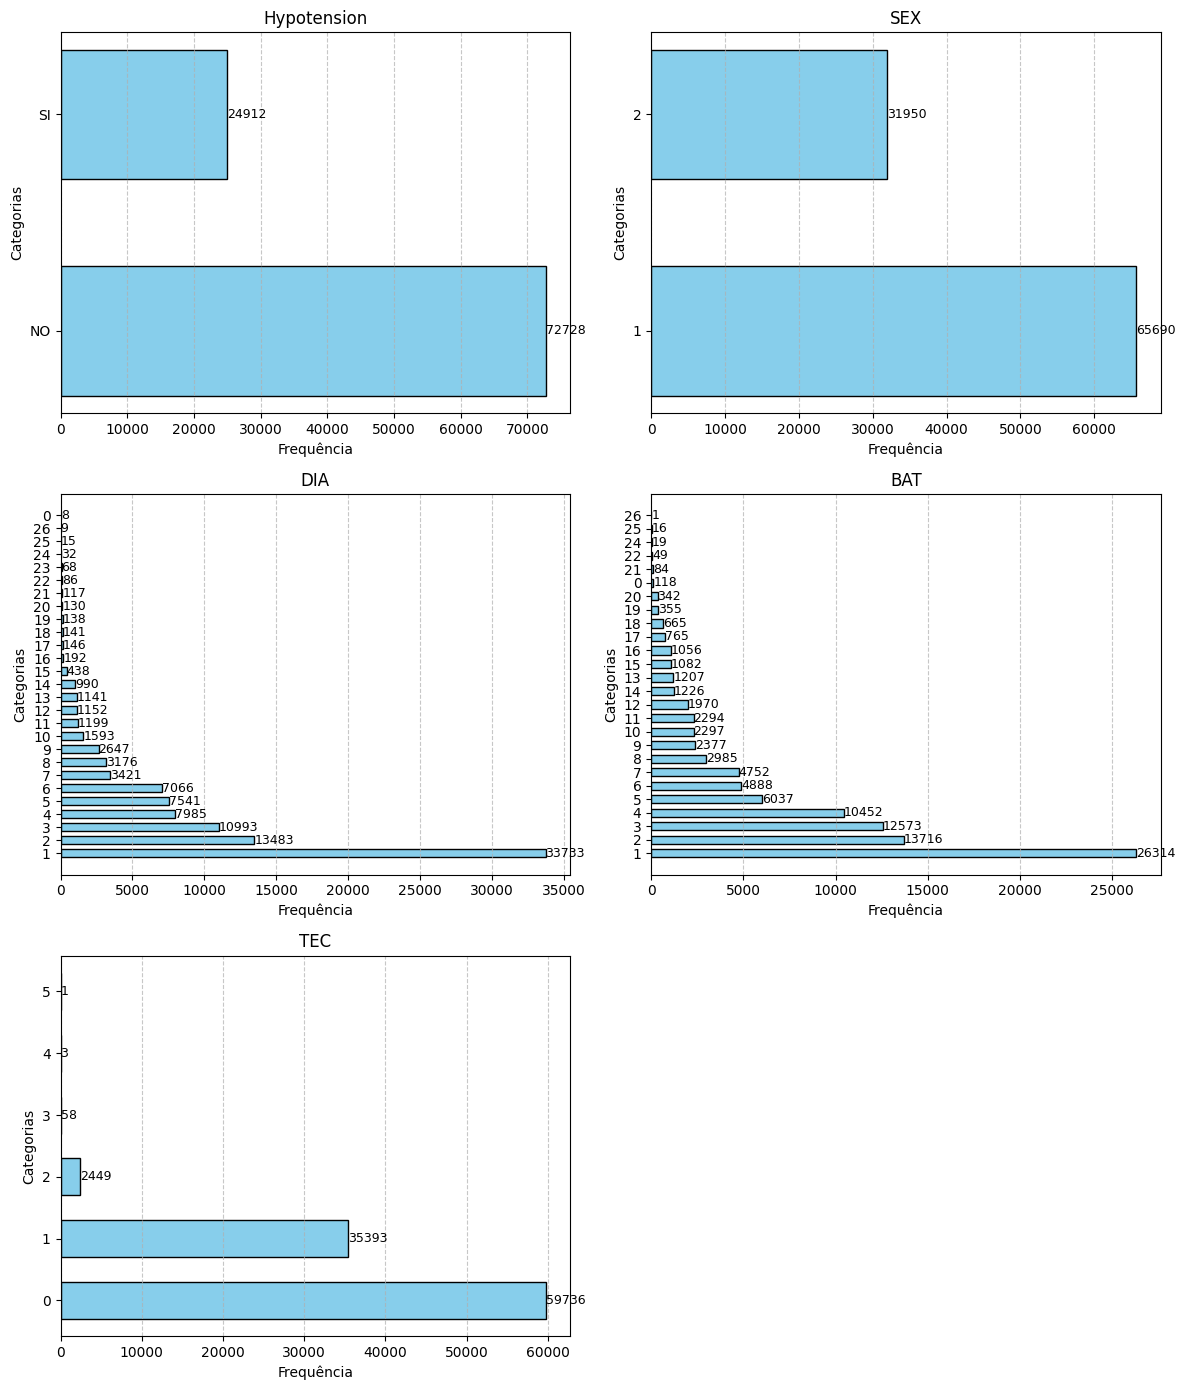

In [66]:
# Criar uma grade de subplots (2x2)
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(nominal_attributes):
  # Contar frequências
  counts = nominal_data[col].value_counts()
  # Gráfico de barras vertical
  axes[i].barh(counts.index.astype(str), counts.values, color="skyblue", edgecolor="black", height=0.6)
  axes[i].set_title(col)
  axes[i].set_ylabel("Categorias")
  axes[i].set_xlabel("Frequência")
  axes[i].grid(axis="x", linestyle="--", alpha=0.7)

  # Adicionar valores ao lado de cada barra
  for j, val in enumerate(counts.values):
    axes[i].text(val + 0.5, j, str(val), va="center", fontsize=9)

# Remover subplots vazios (se sobrar espaço na grade)
for j in range(i+1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Nesse caso, o artigo fornece alguns gráficos com os atributos categóricos. Logo, podemos comparar suas distribuições para descobrir qual o correpondente categórico. Posteriormente, isto pode obviamente ajudar na explicabilidade dos resultados.

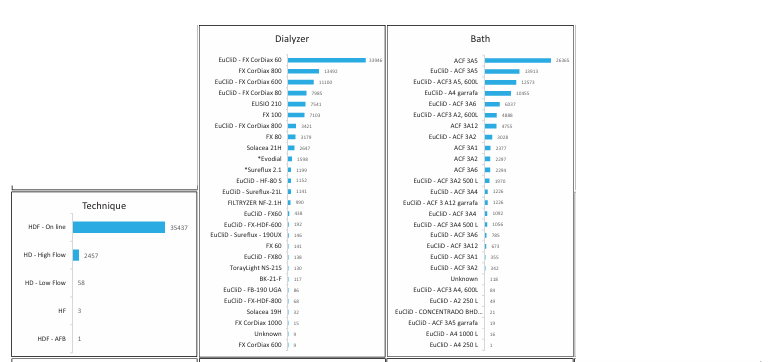


#### Dia (Dialyzer)

Nesse caso, percebe-se que a distribuição explicitada no artigo se assemelha muito à encontrada nos graficos acima. Portanto, pode-se supor que os atributos correspondem aos mesmos de sua distribuição aproximada (eg. 1 = *EuCliD - Fx CorDiax 60*, 2 = *Fx CorDiax 800* e assim por diante).

Ademais, destaca-se a utilização do valor 0 para representar o *unknown*.

| Representação Numérica | Dializador |
|------------------------|------------|
| 1                      | EuCliD - FX CorDiax 60 
| 2                      | FX CorDiax 800
| 3                      | EuCliD - FX CorDiax 600
| 4                      | EuCliD - FX CorDiax 80
| 5                      | ELISIO 210
| 6                      | FX 100
| 7                      | EuCliD - FX CorDiax 800
| 8                      | FX 80
| 9                      | Solacea 21H
| 10                     | Evodial
| 11                     | Sureflux 2.1
| 12                     | EuCliD - HF-80 S
| 13                     | EuCliD - Sureflux-21L
| 14                     | FILTRYZER NF-2.1H
| 15                     | EuCliD - FX60
| 16                     | EuCliD - FX-HDF-600
| 17                     | EuCliD - Sureflux - 190UX
| 18                     | FX 60
| 19                     | EuCliD - FX80
| 20                     | TorayLight NS-21S
| 21                     | BK-21-F
| 22                     | EuCliD - FB-190 UGA
| 23                     | EuCliD - FX-HDF-800
| 24                     | Solacea 19H
| 25                     | FX CorDiax 1000
| 26                     | FX CorDiax 600

#### BAT (Bath)

De forma semelhante ao caso anterior, a distribuição se assemelha muito à encontrada no artigo. Logo, também pode-se supor valores equivalentes (eg. 1 = ACF 3A5, 2 = EuCliD - ACF 3A5 e assim por diante).

Nesse caso, novamente ele utiliza o valor 0 para representar o valor *unknown*.

#### TEC (Technique)

Nesse caso, temos um problema, pois a quantidade de valores possíveis para o atributo no artigo (5) é menor do que a que conseguimos no gráifico (6).

Contudo, tendo em vista os atributos anteriormente analizados, percebe-se que o valor com maior volume no histograma é o correspondente ao 0 e esse pode ser assumido como *unknown*. Dessa forma, entende-se que o autor do artigo optou por ocultar o valor neste caso, por ele representar o maior volume da variável.

#### Hypotension


O Artigo fornece um gráfico de pizza com a porcentagem de sessões de hemodiálise que tiveram ou não casos de hipotensão.

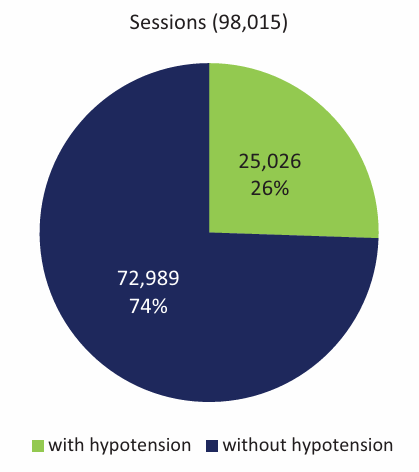



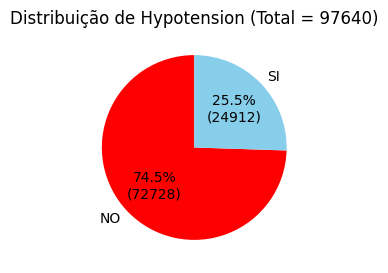

In [67]:
# Contar frequências dos valores da coluna Hypotension
counts = df["Hypotension"].value_counts()

# Função para mostrar porcentagem e valor bruto
def autopct_format(pct, all_vals):
    absolute = int(round(pct/100.*sum(all_vals)))
    return f"{pct:.1f}%\n({absolute})"

# Criar gráfico de pizza
plt.figure(figsize=(3,3))
plt.pie(counts.values,
        labels=counts.index.astype(str),
        autopct=lambda pct: autopct_format(pct, counts.values),
        startangle=90,
        colors=["red","skyblue"])

plt.title(f"Distribuição de Hypotension (Total = {len(df)})")
plt.show()

Como podemos perceber, a distribuição está muito próxima da encontrada no artigo.

A diferença pode ser explicada pela diferença no número total de sessões contabilizadas (98015 no caso do artigo e 9760 disponíveis no *Dataset*), haja visto que de acordo com a descrição do dataset. somente sessões válidas (sem valores NULLs, por exemplo) foram contabilizadas.

#### SEX

Nesse caso, o artigo não fornece um gráfico da distribuição das Sessões por Gênero, mas fornece um gráfico de Sessões por Paciente.

Embora sejam conceitos semelhantes, eles não são idênticos, pois o artigo não estabeleceu um número equivalente de sessões por paciente e no caso do nosso conjunto de dados, não temos um ID para cada paciente.

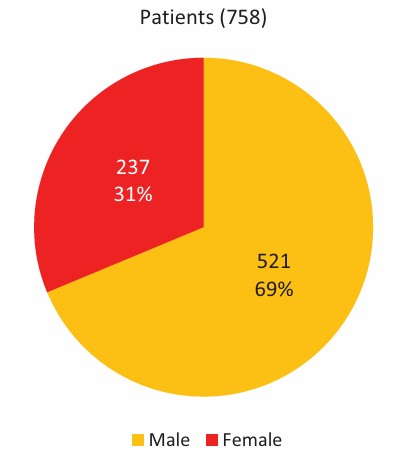

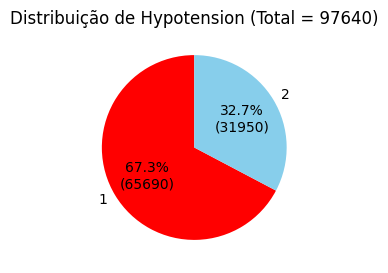

In [68]:
# Contar frequências dos valores da coluna Hypotension
counts = df["SEX"].value_counts()

# Função para mostrar porcentagem e valor bruto
def autopct_format(pct, all_vals):
    absolute = int(round(pct/100.*sum(all_vals)))
    return f"{pct:.1f}%\n({absolute})"

# Criar gráfico de pizza
plt.figure(figsize=(3,3))
plt.pie(counts.values,
        labels=counts.index.astype(str),
        autopct=lambda pct: autopct_format(pct, counts.values),
        startangle=90,
        colors=["red","skyblue"])

plt.title(f"Distribuição de Hypotension (Total = {len(df)})")
plt.show()

Apesar dos pontos citados acima, como as distribuições se mostram muito semelhantes, pode-se interpretar 1 = *Male* e 2 = *Female*, se considerarmos um número aproximado de sessões entre cada paciente.

### Visualização dos atributos numéricos

In [69]:
numeric_attributes = ["AGE","WDR","WPR","WPO","IWG", "HBT","VOL","KT","BFR","HBF","HBC","BSC",
                      "APR","VPR","TMP", "SBP","DBP","HRA","TUF","BOT"]
numeric_data = df[numeric_attributes]

numeric_data.head()

,AGE,WDR,WPR,WPO,IWG,HBT,VOL,KT,BFR,HBF,HBC,BSC,APR,VPR,TMP,SBP,DBP,HRA,TUF,BOT
0,69,0.0,0.0,0.0,0.0,0.0,0.00,25.5,300.0,454.0,13.7,0.0,-125.0,110.0,20.0,130.0,48.0,77.0,0.10,37.2
1,69,0.0,0.0,0.0,0.0,0.0,42.81,41.7,250.0,806.0,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
2,69,0.0,0.0,0.0,0.0,0.0,25.95,65.9,400.0,569.0,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
3,69,0.0,0.0,0.0,0.0,0.0,25.21,63.1,400.0,473.0,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
4,69,69.0,70.0,68.6,1.0,0.0,26.17,62.7,360.0,811.0,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3


Nesta etapa, usou-se o **describe** para ter uma noção geral dos atributos numéricos, o que permitiu notar alguns pontos de atenção que devem ser considerados antes de aplicar os modelos de predição:

*   **Zero em variáveis que não deveriam ser zero:** **VOL, KT, BFR, HBF, HBC, BSC** e  **BOT** têm alguns valores em zero, o que indica medição equivocada ou ausência de medição.
* **Outliers**: Valores de máximo como os de **WDR** muito discrepantes em relação à média indicam outliers que devem ser tratados.

In [70]:
numeric_data.describe()

,AGE,WDR,WPR,WPO,IWG,HBT,VOL,KT,BFR,HBF,HBC,BSC,APR,VPR,TMP,SBP,DBP,HRA,TUF,BOT
count,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000,97640.000000
mean,70.293691,70.160939,71.314864,69.268299,1.758394,27.908922,13.188794,54.843001,413.285139,243.818630,14.085632,0.191868,-181.167739,173.152980,102.727079,124.387126,60.651966,66.467503,1.061197,13.222380
std,15.245558,19.998256,21.189362,21.386481,1.160270,14.752139,14.803812,15.241435,87.550235,329.814789,9.424336,2.470634,55.653363,50.155004,68.415751,36.562483,19.864586,18.814375,29.495810,17.548694
min,19.000000,0.000000,0.000000,0.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-440.000000,-260.000000,-155.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,62.000000,59.800000,61.200000,59.300000,1.000000,35.500000,0.000000,50.700000,370.000000,0.000000,13.800000,0.000000,-220.000000,140.000000,40.000000,110.000000,51.000000,60.000000,0.140000,0.000000
50%,74.000000,69.500000,71.400000,69.500000,1.700000,35.500000,2.695000,57.500000,420.000000,0.000000,13.800000,0.000000,-185.000000,180.000000,80.000000,128.000000,61.000000,68.000000,0.340000,0.000000
75%,82.000000,81.000000,83.200000,81.200000,2.400000,36.000000,25.500000,63.500000,480.000000,512.000000,14.000000,0.000000,-150.000000,200.000000,175.000000,145.000000,72.000000,76.000000,0.610000,36.300000
max,97.000000,885.000000,183.000000,816.000000,10.000000,37.000000,500.000000,122.700000,600.000000,1198.000000,143.000000,140.000000,715.000000,725.000000,504.000000,279.000000,223.000000,244.000000,2700.000000,40.200000


Observação: Normalmente, não faria sentido variáveis como APR e VPR serem negativas. Contudo, no contexto da hemodiálise sim, pois elas indicam,

APR (Pressão arterial) - Pré-bomba:

* É medida no segmento do circuito que puxa sangue do paciente para a bomba.
* Como a bomba gera sucção, essa pressão costuma ser negativa em relação à atmosférica.

VPR (Pressão venosa) - Pós-filtro:
* É medida após o filtro, antes de o sangue retornar ao paciente.
* Aqui a bomba está empurrando o sangue, então a pressão é positiva.

#### Comparação com Artigo

Nesse caso, o artigo também fornece gráficos para compararmos os resultados. Para correta interpretação destes, é importante destacar que antes de plotar a distribuição, os dados foram ordenados de forma crescente de acordo com a variável analisada.

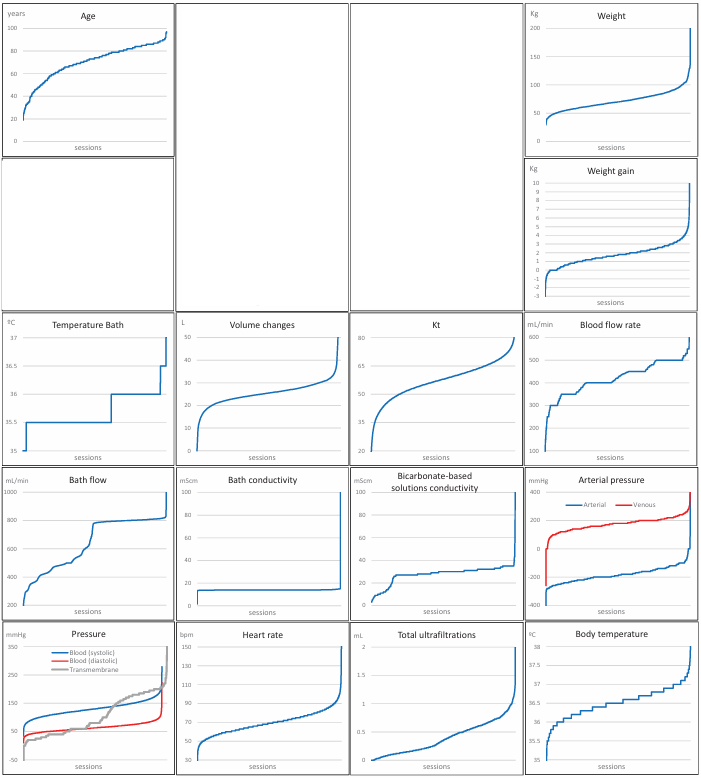

In [71]:
variaveis = ["AGE","WDR","WPR","WPO","IWG", "HBT","VOL","KT","BFR","HBF","HBC","BSC",
             "APR","VPR","TMP", "SBP","DBP","HRA","TUF","BOT"]

unidades = ["Years","Kg","Kg","Kg","Kg", "ºC","L","L","mL/min","mL/min","mScm","mScm",
            "mmHG","mmHG","mmHG", "mmHG","mmHG","bpm","mL","ºC"]

descricoes = ["Age","Weight(dry)","Weight(pre)","Weight(post)","Interdialytic weight gain",
              "Hemodialysis bath temperature","Volume changes","Urea clearance","Blood flowrate",
              "Hemodialysis bath flow","Hemodialysis bath conductivity",
              "Bicarbonate-based solutions conductivity","Arterial pressure","Venous pressure",
              "Transmembrane pressure","Systolic Blood Pressure","Diastolic Blood Pressure", "Heart rate","Total ultrafiltrations","Body temperature"]

In [72]:
# Criar um dicionário para mapear cada variável às suas informações
info = {var: {"unidade": uni, "descricao": desc}
        for var, uni, desc in zip(variaveis, unidades, descricoes)}
info

{'AGE': {'unidade': 'Years', 'descricao': 'Age'},
 'WDR': {'unidade': 'Kg', 'descricao': 'Weight(dry)'},
 'WPR': {'unidade': 'Kg', 'descricao': 'Weight(pre)'},
 'WPO': {'unidade': 'Kg', 'descricao': 'Weight(post)'},
 'IWG': {'unidade': 'Kg', 'descricao': 'Interdialytic weight gain'},
 'HBT': {'unidade': 'ºC', 'descricao': 'Hemodialysis bath temperature'},
 'VOL': {'unidade': 'L', 'descricao': 'Volume changes'},
 'KT': {'unidade': 'L', 'descricao': 'Urea clearance'},
 'BFR': {'unidade': 'mL/min', 'descricao': 'Blood flowrate'},
 'HBF': {'unidade': 'mL/min', 'descricao': 'Hemodialysis bath flow'},
 'HBC': {'unidade': 'mScm', 'descricao': 'Hemodialysis bath conductivity'},
 'BSC': {'unidade': 'mScm',
  'descricao': 'Bicarbonate-based solutions conductivity'},
 'APR': {'unidade': 'mmHG', 'descricao': 'Arterial pressure'},
 'VPR': {'unidade': 'mmHG', 'descricao': 'Venous pressure'},
 'TMP': {'unidade': 'mmHG', 'descricao': 'Transmembrane pressure'},
 'SBP': {'unidade': 'mmHG', 'descricao': 

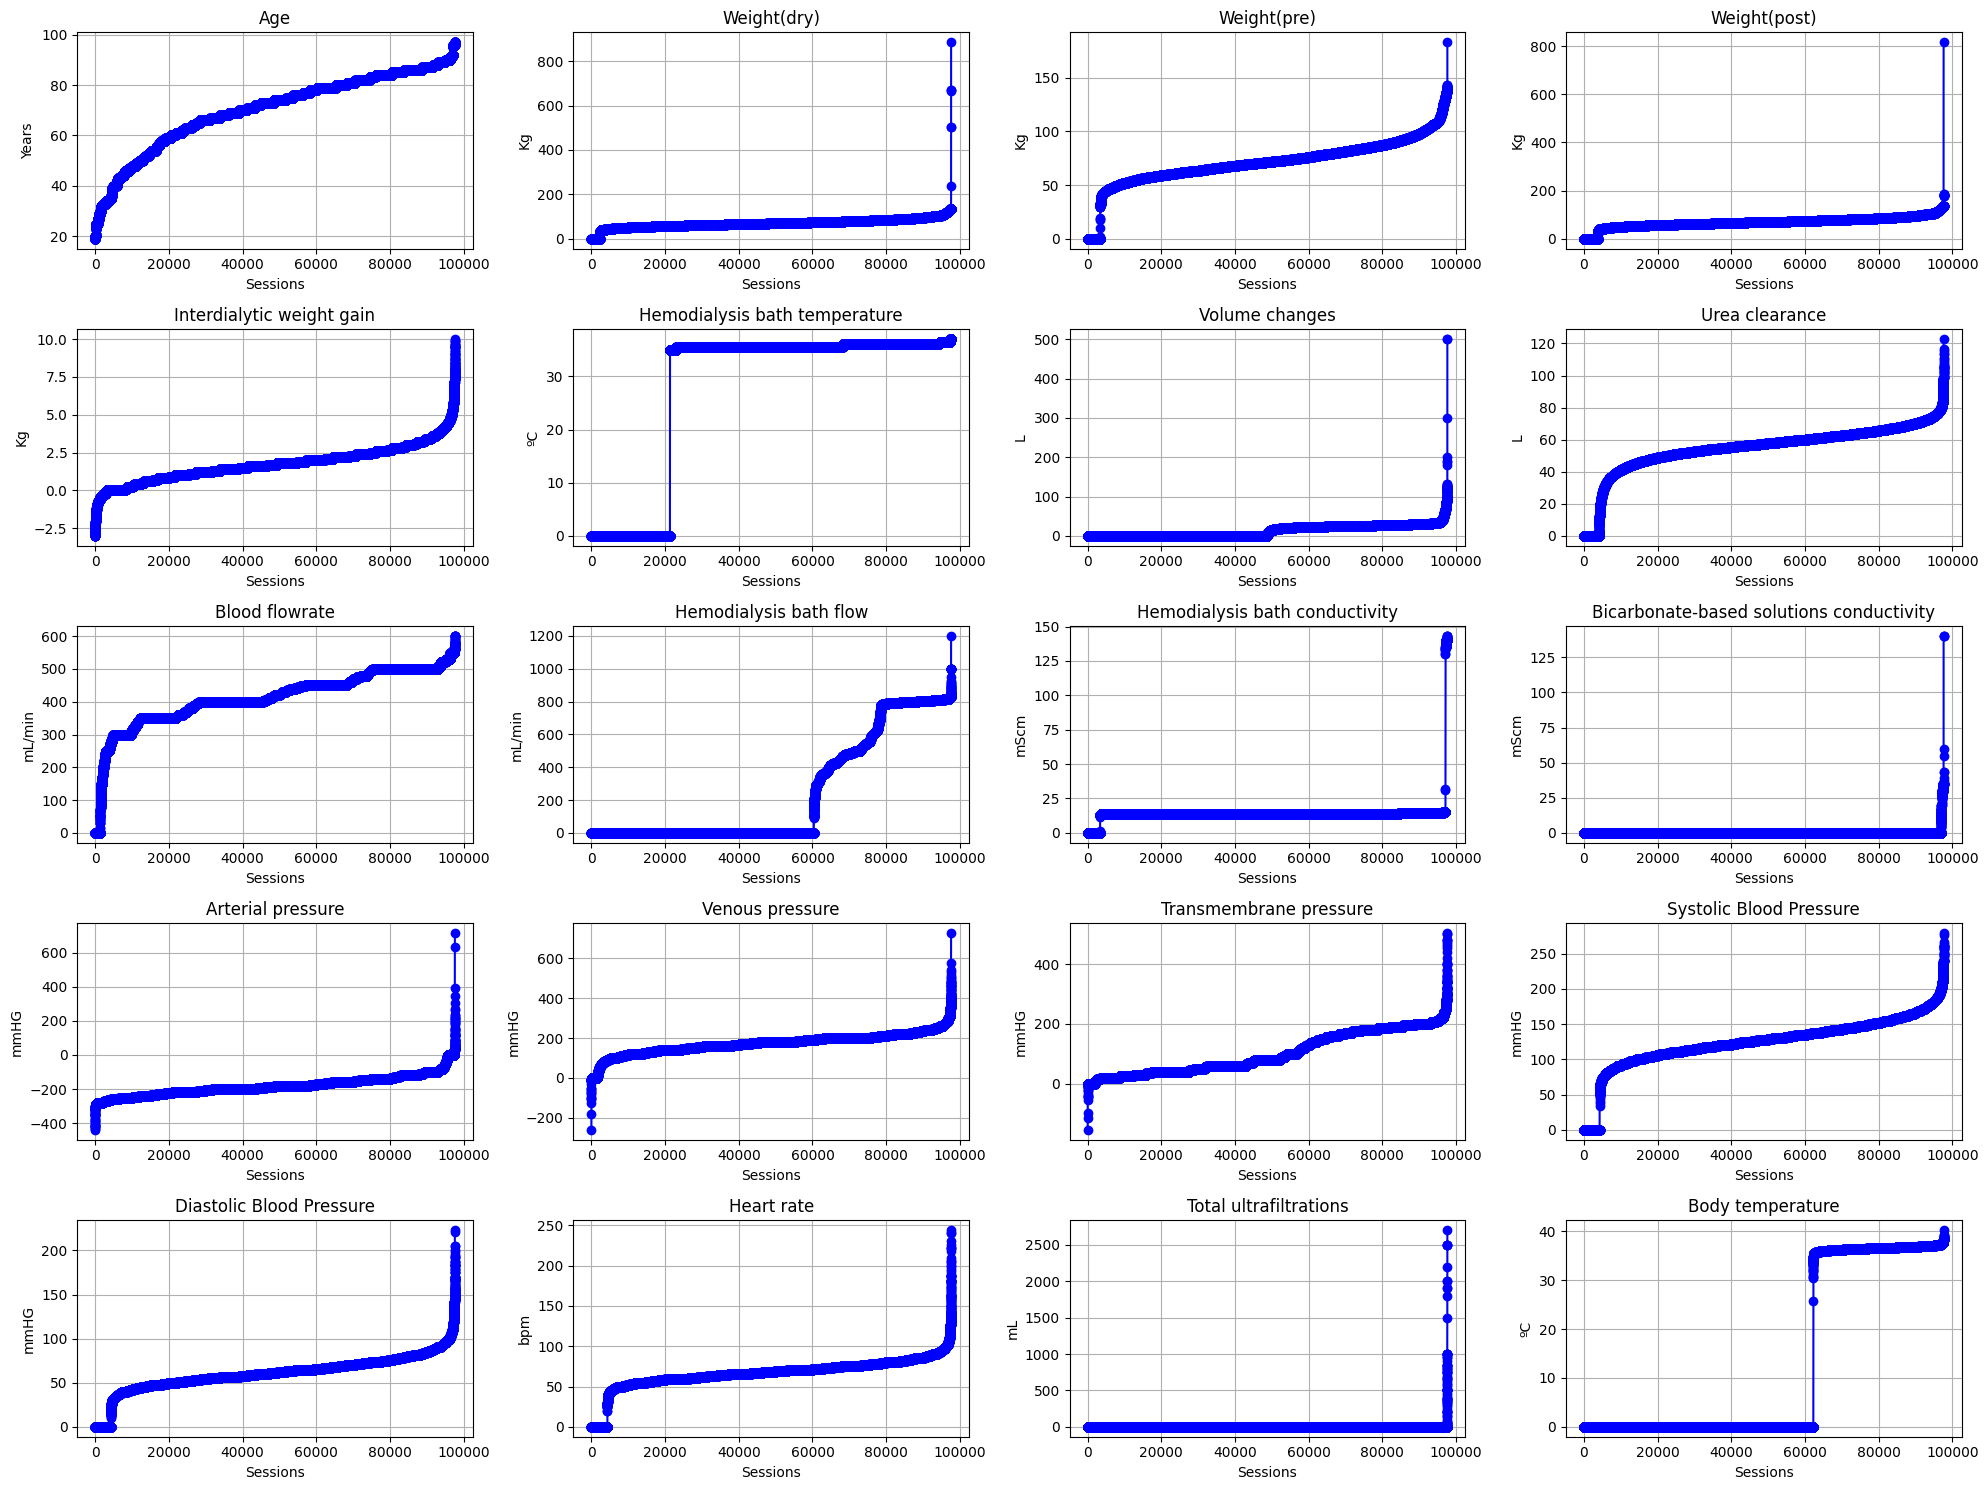

In [73]:
# Número de variáveis
n = len(variaveis) # Definir número de linhas e colunas da grade
cols = 4 # quantidade de gráficos por linha
rows = (n + cols - 1) // cols # calcula quantas linhas serão necessárias

fig, axes = plt.subplots(rows, cols, figsize=(5*cols,3*rows))

# Flatten para iterar facilmente
axes = axes.flatten()

for i, var in enumerate(variaveis):
  df_sorted = df.sort_values(by=var)
  axes[i].plot(range(len(df_sorted)), df_sorted[var], marker="o", linestyle="-", color="blue")
  axes[i].set_title(descricoes[i])
  axes[i].set_xlabel("Sessions")
  axes[i].set_ylabel(unidades[i])
  axes[i].grid(True)

# Remover subplots vazios (se sobrar espaço na grade)
for j in range(i+1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Como pode-se observar, os pontos de atenção destacado anteriormente (muitos valores zero - os quais podem indicar leitura incorreta ou ausência de leitura - e outliers) podem ser observados graficamente. Desta forma, vamos analisar os atributos um a um:

*   **AGE**: Distribuição está de acordo com a encontrada no artigo e em uma distribuição aceitável (sem outliers ou valores zero em excesso);
* **WDR, WPR e WPO**: Nesse caso, percebe-se a presença de valores zero - o que não faz sentido até pela natureza das variáveis - e ouliers (Exemplo: pessoas com WDR (peso seco em kg) acima de 800 kg);
*   **IWG**: Nesse caso, percebe-se uma distribuição de acordo com a encontrada no artigo.
* **HBT**: Grande presença de valores zero, o que prejudicou a visualização do gráfico. Logo, segue abaixo o gráfico sem os valores zero e como pode-se perceber, estes batem com os registros do artigo.

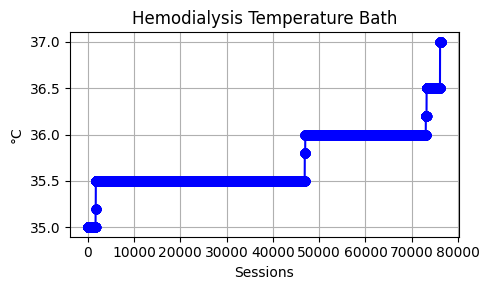

In [74]:
df_hbt = df[df["HBT"] != 0].sort_values(by="HBT")

# Índice sequencial para sessões
sessions = range(len(df_hbt))
temperaturas = df_hbt["HBT"]

# Criar gráfico
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(sessions, temperaturas, marker="o", linestyle="-", color="blue")

# Configurações visuais
ax.set_title("Hemodialysis Temperature Bath")
ax.set_xlabel("Sessions")
ax.set_ylabel("°C")
ax.grid(True)

plt.tight_layout()
plt.show()

* **VOL, HBF, BSC, TUF e BOT**: Nesse caso, percebe-se também percebe-se a grande influência dos valores zero e de outliers no gráfico. Logo, é essencial que depois sejam pré-processados.
* **KT, BFR, HBC, APR, VPR, TMP, SBP, DBP e HRA**: Embora haja influência dos zeros e outliers na distribuição, ela já está consideravelmente próxima do aceitável.

### Tratamento de zeros artificiais e Outliers

Como pudemos perceber acima, há grande influência dos zeros artificiais (representantes de valores nulos ou inválidos) e *outliers* na distribuição atributos numéricos.

Sendo assim, para obter uma representação mais próxima da realidade, deve-se eliminar esses dois ruídos.

#### Substituição dos zeros artificiais por NaN

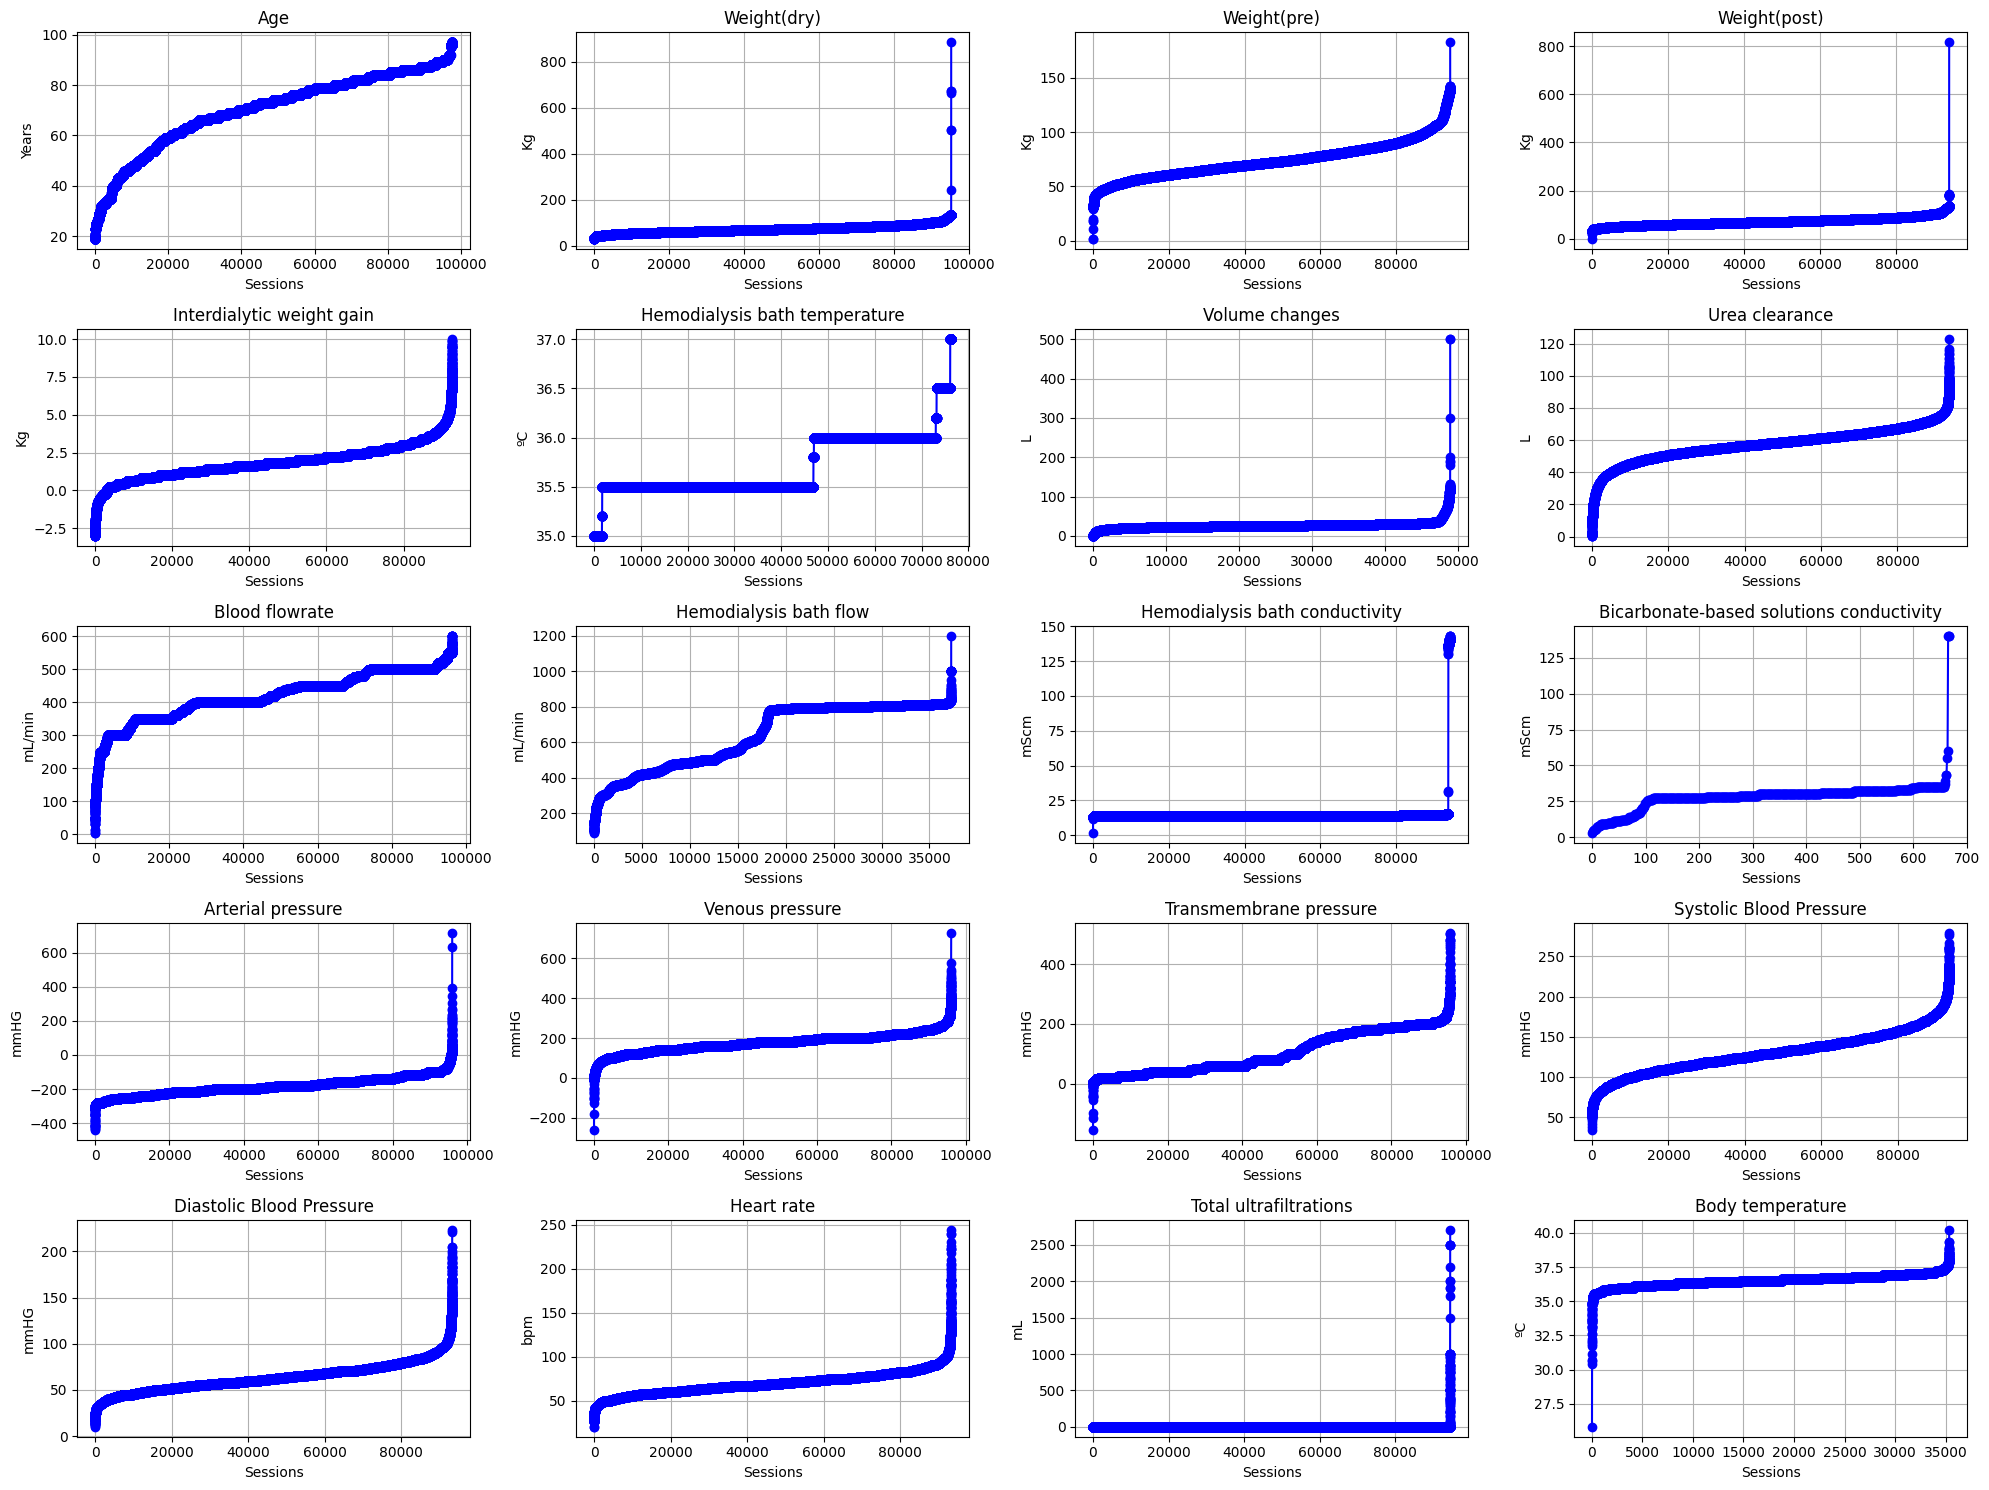

In [75]:
# Substituir zeros por NaN em todas as variáveis
df_clean = df.copy()
df_clean[variaveis] = df_clean[variaveis].replace(0, np.nan)

# Número de variáveis
n = len(variaveis)
cols = 4  # quantidade de gráficos por linha
rows = (n + cols - 1) // cols  # calcula quantas linhas serão necessárias

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    # Ordena ignorando NaN
    df_sorted = df_clean.sort_values(by=var)

    # Plota distribuição
    axes[i].plot(range(len(df_sorted)), df_sorted[var], marker="o", linestyle="-", color="blue")
    axes[i].set_title(descricoes[i])   # títulos descritivos
    axes[i].set_xlabel("Sessions")
    axes[i].set_ylabel(unidades[i])    # unidades correspondentes
    axes[i].grid(True)

# Remove subplots vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Como pode-se perceber, alguns resultados já se encontram muito mais próximos de uma distribuição real, ao exemplo do próprio **HBT**. Todavia, ainda há diversas distribuições com resultados fora da realidade (eg. VOL próximo há 500 L).

#### Remoção de outliers

Para solucionar os Outliers, pode-se aplicar o IQR (*Interquartile Range*):
* Calcula o intervalo entre o 1º quartil (Q1) e o 3º quartil (Q3);
* Define como *outlier* qualquer valor fora de:

**[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]**

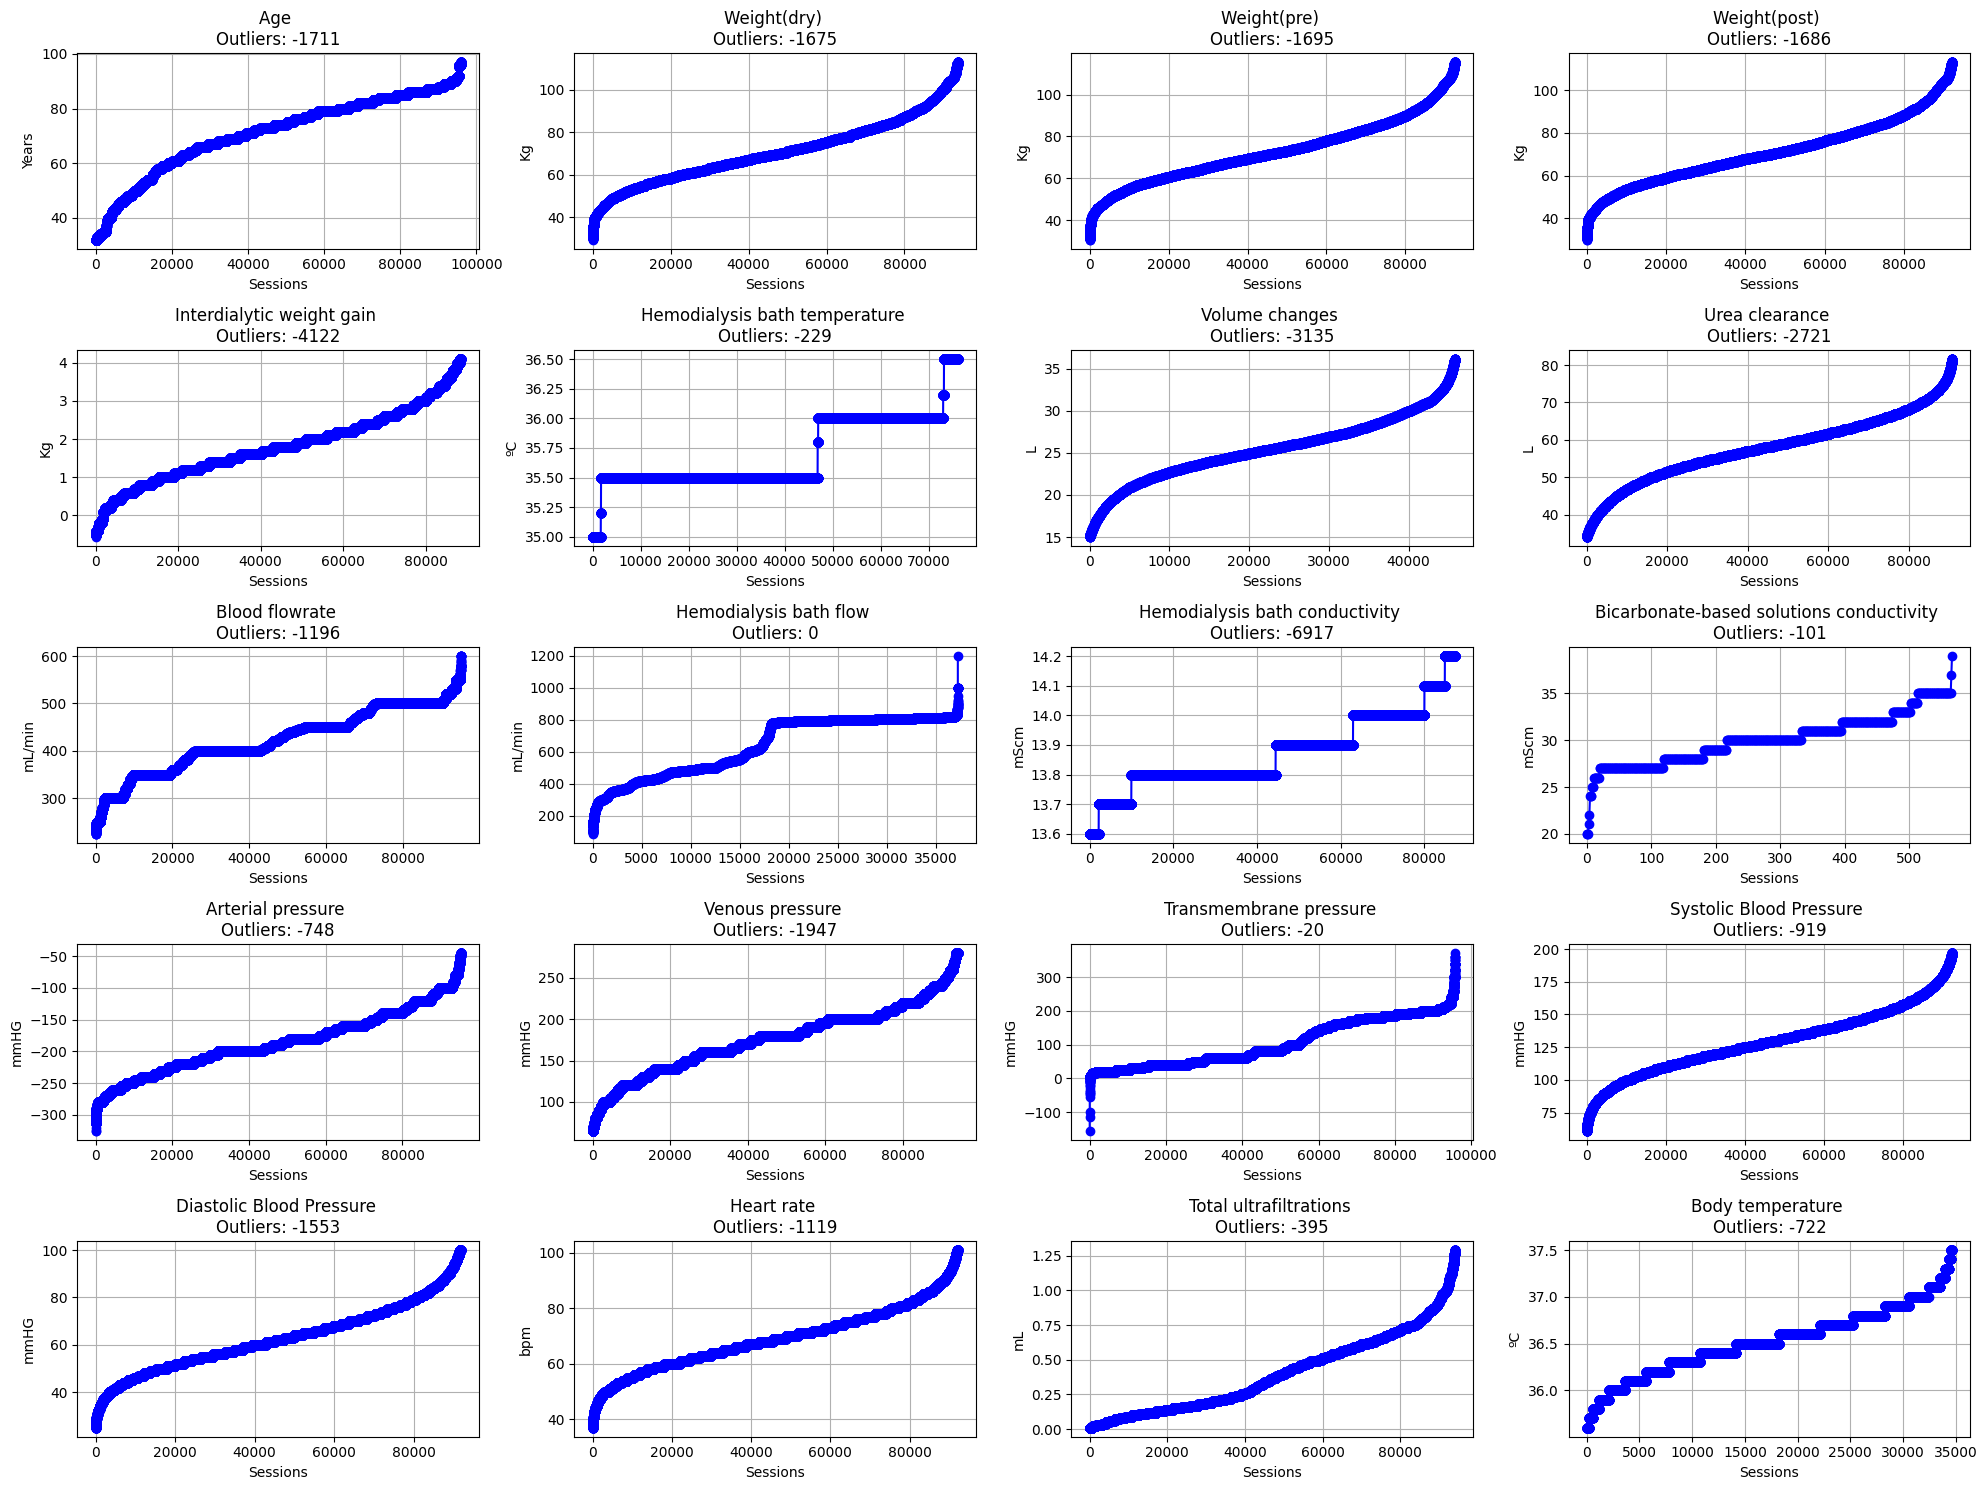

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Função para remover outliers via IQR
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.where((series >= lower_bound) & (series <= upper_bound), np.nan)

# Dicionário para armazenar contagem de outliers
outliers_count = {}

# Aplicar a função em todas as variáveis
for var in variaveis:
    original = df_clean[var].copy()
    df_clean[var] = remove_outliers_iqr(original)
    # Contar quantos valores viraram NaN (ou seja, eram outliers)
    outliers_count[var] = original.isna().sum() - df_clean[var].isna().sum()

# Número de variáveis
n = len(variaveis)
cols = 4  # quantidade de gráficos por linha
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    # Ordena ignorando NaN
    df_sorted = df_clean.sort_values(by=var)

    # Plota distribuição
    axes[i].plot(range(len(df_sorted)), df_sorted[var], marker="o", linestyle="-", color="blue")
    axes[i].set_title(f"{descricoes[i]} \nOutliers: {outliers_count[var]}")
    axes[i].set_xlabel("Sessions")
    axes[i].set_ylabel(unidades[i])
    axes[i].grid(True)

# Remove subplots vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Dessa forma, percebe-se distribuições muito mais próximas das encontradas no artigo e também em sua maioria, com comportamento próximo ao linear.

In [77]:
print("Contagem de atributos NaN por atributo (%): \n")
print((df_clean.isna().sum() / len(df_clean) * 100).round(2))

Contagem de atributos NaN por atributo (%): 

Hypotension     0.00
SEX             0.00
AGE             1.75
DIA             0.00
BAT             0.00
TEC             0.00
WDR             4.05
WPR             5.21
WPO             5.62
IWG             9.39
HBT            22.07
VOL            53.08
KT              6.99
BFR             2.65
HBF            61.83
HBC            10.53
BSC            99.42
APR             2.50
VPR             3.60
TMP             1.96
SBP             5.31
DBP             5.97
HRA             5.59
TUF             3.62
BOT            64.52
dtype: float64


Ademais, pode-se perceber que alguns atributos possuem um grande volume de valores nulos em relação ao total - resultantes dos tratamentos que acabamos de fazzer. Portanto, posteriormente deve-se analiar se eles serão removidos ou se será utilizada uma técnica de imputação de dados.

### Correlação

Visto que os dados apresentão distribuição aproximadamente linear e dado o devido tratamento aos dados (outliers e zeros artificais infleunciam fortemente), podemos utilizar a **Correlação de Pearson**.

Nesta etapa, nós desejamos calcular a correlação da variável alvo **Hypotension** em relação às variáveis numéricas. Todavia, como Hypotension se trata de uma variável binária onde *SI* representa que há hipotensão e *NO* representa que não há, devemos transformar seus valores em numéricos. logo,


*  *SI = 1*
*  *NO = 0*



In [78]:
corr_attributes = ["Hypotension","AGE","WDR","WPR","WPO","IWG", "HBT","VOL","KT","BFR","HBF","HBC","BSC",
                      "APR","VPR","TMP", "SBP","DBP","HRA","TUF","BOT"]
corr_data = df_clean[corr_attributes]

# Define 0s artificias como NaN
corr_data[variaveis] = corr_data[variaveis].replace(0, np.nan)

# Função para remover outliers via IQR
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.where((series >= lower_bound) & (series <= upper_bound), np.nan)

# Aplicar a função em todas as variáveis
for var in variaveis:
    corr_data[var] = remove_outliers_iqr(corr_data[var])

# Transforma Hypotension em binário: SI -> 1, NO -> 0
corr_data["Hypotension"] = corr_data["Hypotension"].map({"SI": 1, "NO": 0})

corr_data.head()

,Hypotension,AGE,WDR,WPR,WPO,IWG,HBT,VOL,KT,BFR,...,HBC,BSC,APR,VPR,TMP,SBP,DBP,HRA,TUF,BOT
0,0,69.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.0,...,13.7,NaN,-125.0,110.0,20.0,130.0,48.0,77.0,0.10,37.2
1,0,69.0,NaN,NaN,NaN,NaN,NaN,NaN,41.7,250.0,...,13.6,NaN,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
2,0,69.0,NaN,NaN,NaN,NaN,NaN,25.95,65.9,400.0,...,13.7,NaN,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
3,0,69.0,NaN,NaN,NaN,NaN,NaN,25.21,63.1,400.0,...,13.6,NaN,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
4,0,69.0,69.0,70.0,68.6,1.0,NaN,26.17,62.7,360.0,...,13.7,NaN,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3


Para demonstrar a correlação entre as variáveis nesse caso, nós utilizaremos um **heatmap de matriz de correlação**. Cada célula deste mostra o coeficiente de correlação entre duas variáveis, e a intensidade da cor indica a força e o sinal dessa relação.

Nesse caso, como o atributo alvo é binário, pode-se interpretar os dados da seguinte forma:

* **Valores próximos de +1:** forte correlação positiva (se a variável X cresce, a chance de *Hypotension=1* aumenta);
* **Valores próximos de -1:** forte correlação negativa (se a variável X cresce, a chance de *Hypotension=1* diminui);
* **Valores próximos de 0:** pouca ou nenhuma relação linear entre as variáveis.

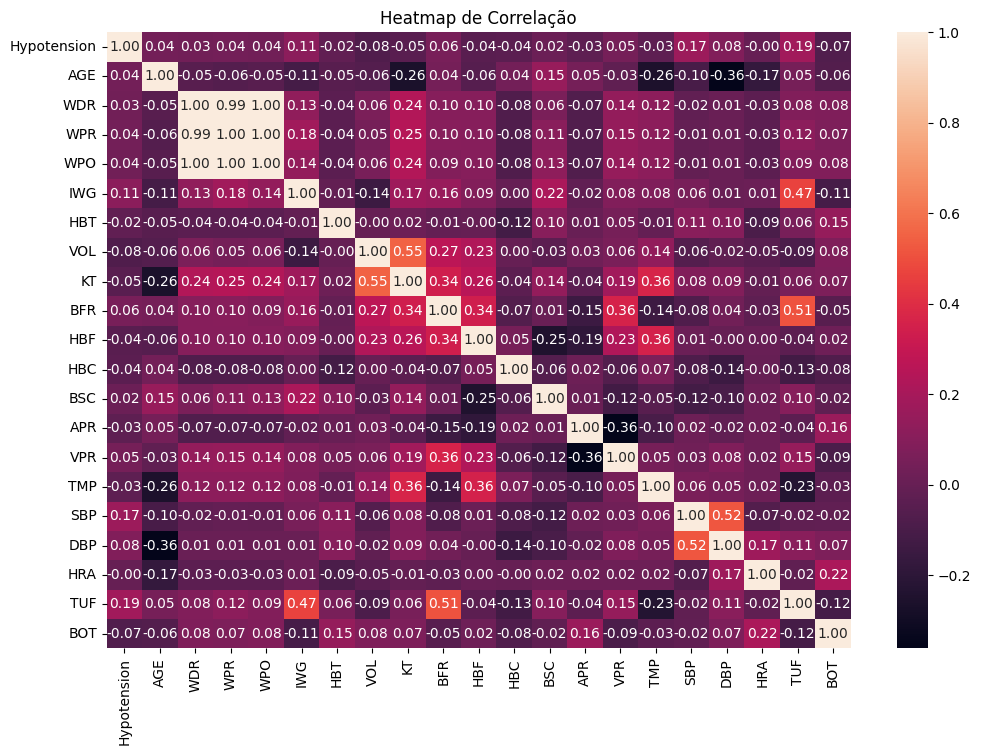

In [79]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f")
plt.title("Heatmap de Correlação")
plt.show()

Dessa forma, como pode-se perceber, os atributos que mais se correlacionam com **Hypotension** são: **IWG, VOL, SBP, DBP** e **TUF**.

## 2. Seleção de Atributos

Tendo em vista o volume de valores nulos (NaN) por atributos e a correlação destes em relação ao atributos alvo, foram selecionados os atributos que serão utilizados posteriormente no treinamento dos modelos. Dessa forma, optou-se por remover:

* **VOL** (53%), **HBF** (62%), **BOT** (65%), **BSC** (99%) e **TEC** (61%) - Pela baixa qualidade dos dados (>50% dos dados nulos), o que requisitaria uma imputação considerável e possivelmente, causaria viés;
* **HBT** (0.02) e **HRA**(0.00) - Pela baixa correlação com o atributo alvo (>=0.02).

Os demais atributos serão tratados individualmente com a remoção dos objetos que possuem valor NaN ou aplicação de técnicas de imputação à depender do quanto os valores faltantes afetem ao todo.


In [80]:
selecteted_attributes = ["Hypotension","SEX","AGE","DIA","BAT",
                         "WDR","WPR","WPO","IWG","KT","BFR","HBC",
                         "APR","VPR","TMP","SBP","DBP","TUF"]

df = df_clean[selecteted_attributes]

df

,Hypotension,SEX,AGE,DIA,BAT,WDR,WPR,WPO,IWG,KT,BFR,HBC,APR,VPR,TMP,SBP,DBP,TUF
0,NO,1,69.0,10,1,NaN,NaN,NaN,NaN,NaN,300.0,13.7,-125.0,110.0,20.0,130.0,48.0,0.10
1,NO,1,69.0,8,1,NaN,NaN,NaN,NaN,41.7,250.0,13.6,-100.0,80.0,150.0,146.0,46.0,0.10
2,NO,1,69.0,8,1,NaN,NaN,NaN,NaN,65.9,400.0,13.7,-175.0,155.0,35.0,137.0,58.0,0.11
3,NO,1,69.0,8,1,NaN,NaN,NaN,NaN,63.1,400.0,13.6,-170.0,155.0,200.0,153.0,67.0,0.09
4,NO,1,69.0,8,1,69.0,70.0,68.6,1.0,62.7,360.0,13.7,-155.0,120.0,185.0,138.0,55.0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97635,NO,1,82.0,1,15,71.0,73.7,71.1,2.8,53.0,450.0,13.7,-230.0,140.0,25.0,150.0,67.0,0.74
97636,NO,1,82.0,1,15,71.0,72.8,71.0,1.7,52.8,440.0,13.7,-200.0,155.0,15.0,129.0,60.0,0.51
97637,SI,1,54.0,10,7,NaN,NaN,NaN,NaN,NaN,300.0,NaN,NaN,NaN,NaN,155.0,79.0,NaN
97638,NO,1,54.0,8,7,NaN,NaN,NaN,NaN,53.7,300.0,14.0,-125.0,145.0,130.0,143.0,76.0,0.14


## 3. Tratamento de tuplas vazias e duplicadas

Inicialmente, são retiradas todas as tuplas reconhecidas como duplicadas, visto que não adicionam informação ao conjunto.

In [81]:
print(df.duplicated().sum())
df = df.drop_duplicates()

28


Posteriormente, damos atenção às tuplas com valores nulos, conforme já citamos anteriormente.

In [82]:
print("Contagem de atributos NaN por atributo (%): \n")
print((df.isna().sum() / len(df) * 100).round(2))

Contagem de atributos NaN por atributo (%): 

Hypotension     0.00
SEX             0.00
AGE             1.75
DIA             0.00
BAT             0.00
WDR             4.02
WPR             5.18
WPO             5.59
IWG             9.37
KT              6.96
BFR             2.64
HBC            10.50
APR             2.47
VPR             3.57
TMP             1.93
SBP             5.28
DBP             5.95
TUF             3.59
dtype: float64


Optou-se por não excluir as tuplas com valor nulo, pois elas representariam uma fatia considerável do todo e portanto, utilizaremos imputação de dados para sanar este problema. Ademais, como todos os atributos com algum valor NaN é numérico - vide tabela acima - iremos tratar na próxima seção.

In [83]:
df_copy = df.copy()

len_before = len(df_copy)
df_copy = df_copy.dropna()
len_after = len(df_copy)

removidas = len_before - len_after
percentual = (removidas / len_before) * 100

print(f"Quantidade de linhas que seriam removidas: {removidas} ({percentual:.2f}% do total)")

Quantidade de linhas que seriam removidas: 30998 (31.76% do total)


## 4. Tratamento de Atributos Numéricos 

No caso, a técnica de imputação escolhida foi o **KNN Imputer**, pois ele utiliza os vizinhos mais próximos para estimar valores faltantes, preservando a estrutura dos dados. Dessa forma, relações não-lineares são preservadas e o viés de uma simples imputação por média, mediana, constante (ao exemplo do zero, que tratamos) ou regressão linear é minimizado.

Esse tipo de imputação se faz ainda mais eficiente por já termos tratado dos outliers.

In [84]:
# Categorias já discretizadas (não serão imputadas pelo KNN numérico)
categorical_cols = ['Hypotension', 'SEX', 'DIA', 'BAT']

# Atributos numéricos contínuos (candidatos à imputação)
numeric_cols = [
    "AGE", "WDR", "WPR", "WPO", "IWG",
    "KT", "BFR", "HBC", "APR", "VPR", 
    "TMP", "SBP", "DBP", "TUF"
]

In [85]:
from sklearn.impute import KNNImputer

# ============================================================
# 1. Normalizar os dados numéricos antes do KNN
#    (KNN usa distância → escala importa!)
# ============================================================
scaler = MinMaxScaler()

df_numeric = df[numeric_cols].copy()
df_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric),
    columns=numeric_cols,
    index=df.index
)

# ============================================================
# 2. Aplicar KNN Imputer
#    n_neighbors=5 → média dos 5 vizinhos mais próximos
# ============================================================
imputer = KNNImputer(n_neighbors=5, weights='distance')

df_imputed_scaled = pd.DataFrame(
    imputer.fit_transform(df_numeric_scaled),
    columns=numeric_cols,
    index=df.index
)

# ============================================================
# 3. Reverter a normalização para a escala original
# ============================================================
df_imputed_numeric = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled),
    columns=numeric_cols,
    index=df.index
)

# ============================================================
# 4. Reconstruir o DataFrame completo
# ============================================================
df_final = df[categorical_cols].copy()
df_final = pd.concat([df_final, df_imputed_numeric], axis=1)

# Restaurar a ordem original das colunas
df_final = df_final[df.columns]

# ============================================================
# 5. Verificar resultado
# ============================================================
print("\n=== Valores nulos por atributo (após a imputação) ===")
nulos_depois = df_final.isnull().sum()
nulos_depois = nulos_depois[nulos_depois > 0]

if len(nulos_depois) == 0:
    print("Nenhum valor nulo restante! Imputação concluída com sucesso.")
else:
    print(nulos_depois)

print(f"\nShape original:  {df.shape}")
print(f"Shape após KNN:  {df_final.shape}")

df = df_final


=== Valores nulos por atributo (após a imputação) ===
Nenhum valor nulo restante! Imputação concluída com sucesso.

Shape original:  (97612, 18)
Shape após KNN:  (97612, 18)


## 5. Tratamento de Atributos Categóricos

Primeiramente, podemos mapear **Hypotension** e **SEX** para o formato binário padrão. No caso, 
* Hypotension: 'No' -> 0, 'Si' -> 1
* SEX: 2 -> 1, 1 -> 0

In [86]:
df['Hypotension'] = df['Hypotension'].astype(str).str.strip()
df['Hypotension'] = df['Hypotension'].map({'NO':0,'SI':1})
df['SEX'] = df['SEX'].map({1:0,2:1})

# Converter SEX e Hypotension para inteiros
df['SEX'] = df['SEX'].astype(int)
df['Hypotension'] = df['Hypotension'].astype(int)

Em relação aos demais atributos nominais, podemos excluir as tuplas onde **DIA** e **BAT** apresentam valor 0, pois assim como observado nos atributos numéricos, foram inseridos zeros artificiais onde não se tinha conhecimento da categoria no qual o objeto se enquadrava. Contudo, diferentemente dos atributos numéricos, essas tuplas representam uma fatia mínima do conjunto total.

In [87]:
# Contar quantos valores são 0 em cada coluna
zeros_dia = (df['DIA'] == 0).sum()
zeros_bat = (df['BAT'] == 0).sum()

print(f"Porcentagem de valores 0 em DIA: {(zeros_dia/len(df))*100}%")
print(f"Porcentagem de valores 0 em BAT: {(zeros_bat/len(df))*100}%")

# ============================================
# Exclusão das tuplas com DIA ou BAT == 0
# ============================================
print(f"\nTamanho do DF antes: {len(df)}")
df = df.drop(df[(df['DIA'] == 0) | (df['BAT'] == 0)].index)
print(f"Tamanho do DF depois: {len(df)}")

Porcentagem de valores 0 em DIA: 0.008195713641765356%
Porcentagem de valores 0 em BAT: 0.12088677621603901%

Tamanho do DF antes: 97612
Tamanho do DF depois: 97494


### Balanceamento do atributo BAT

Tendo em vista que o atributo **BAT** possui uma alta gama de classes, optou-se por agrupar condensar os 26 possíveis valores do atributos em 3 grupos. Essa decisão visa não diminuir a quantidade de atributos que posteriormente serão gerados na codificação *One-Hot* e no processo de *Flatenning* do dataframe, mas também balancear a distribuição das classes, haja visto que enquanto a classe em menor quantidade (df['BAT'] == 26) representa apenas 1 tupla, a classe de maior quantidade (df['BAT'] == 1) representa 26314 tuplas.

Com isso, espera-se não só termos uma melhora no desemepnho computacional durante o treinamento dos modelos, mas também uma melhora na generalização destes.

Dessa forma, deve-se gerar três grupos:
1. Apenas com a classe 1 (correspondente ao banho "ACF 3A5");
2. Apenas com as classes 2, 3 e 4 (correspondentes ao banhos "EuCliD - ACF 3A5", "EuCliD - ACF 3A5, 600L" e "EuCliD - A4 garrafa", respectivamente);
3. Com as demais classes.

* **OBS.:** o atributo **DIA** também possui uma ampla gama de classes e portanto, deveria sofre agrupamento. Todavia, iremos utilizá-lo na identificação das sessões de hemodiálise em conjunto com os atributo AGE e SEX, logo, é interessante que mantenhamos uma maior gama de classes para correta identificação das sessões. Afinal, uma sessão de diálise pode até utilzar múltiplos banhos - meio líquido que possibilita a troca de substâncias entre o sangue e o ambiente externo -, mas muito raramente terá mais de um dialisador.

In [88]:
def agrupar_bat(valor):
    if valor == 1:
        return "Grupo 1 - ACF 3A5"
    elif valor in [2, 3, 4]:
        return "Grupo 2 - EuCliD"
    else:
        return "Grupo 3 - Demais classes"

# Criando a nova coluna com os grupos
df['BAT_GROUP'] = df['BAT'].apply(agrupar_bat)
# Excluindo a coluna BAT
df = df.drop(columns=['BAT'])

print("---Distribuição de BAT APÓS do balanceamento:---")
# Visualizando a distribuição dos grupos
print(df['BAT_GROUP'].value_counts())

---Distribuição de BAT APÓS do balanceamento:---
BAT_GROUP
Grupo 2 - EuCliD            36741
Grupo 3 - Demais classes    34453
Grupo 1 - ACF 3A5           26300
Name: count, dtype: int64


### One-Hot Enconding 

Por fim, **BAT** foi transformada em numéricos (binários) para melhor adequação aos modelos que serão aplicados. Assim, foi aplicada a codificação *One-Hot*, onde cada valor único da variável é transformado em uma nova variável binária. Cada nova variável representa a presença ou ausência desse valor na observação original. 

Essa abordagem vai criar uma matriz esparsa com muitas colunas binárias.

In [ ]:
# especificando as colunas alvo da transformação
target_columns = ['BAT_GROUP']

# Convertendo do tipo int para categoria
df[target_columns] = df[target_columns].astype('category')

# usando a função get_dummies
df_encoded_columns = pd.get_dummies(df[target_columns], dtype=int)

# concatenando as novas colunas binárias na tabela e removendo as nominais originais
df = pd.concat([df.drop(columns=target_columns), df_encoded_columns], axis=1)

                      BAT_GROUP
0             Grupo 1 - ACF 3A5
1             Grupo 1 - ACF 3A5
2             Grupo 1 - ACF 3A5
3             Grupo 1 - ACF 3A5
4             Grupo 1 - ACF 3A5
...                         ...
97635  Grupo 3 - Demais classes
97636  Grupo 3 - Demais classes
97637  Grupo 3 - Demais classes
97638  Grupo 3 - Demais classes
97639  Grupo 3 - Demais classes

[97494 rows x 1 columns]
       BAT_GROUP_Grupo 1 - ACF 3A5  BAT_GROUP_Grupo 2 - EuCliD  \
0                                1                           0   
1                                1                           0   
2                                1                           0   
3                                1                           0   
4                                1                           0   
...                            ...                         ...   
97635                            0                           0   
97636                            0                           0

In [90]:
print("Formato dos dados após tratamento dos atributos nominais: ", df.shape)
df.columns

Formato dos dados após tratamento dos atributos nominais:  (97494, 20)


Index(['Hypotension', 'SEX', 'AGE', 'DIA', 'WDR', 'WPR', 'WPO', 'IWG', 'KT',
       'BFR', 'HBC', 'APR', 'VPR', 'TMP', 'SBP', 'DBP', 'TUF',
       'BAT_GROUP_Grupo 1 - ACF 3A5', 'BAT_GROUP_Grupo 2 - EuCliD',
       'BAT_GROUP_Grupo 3 - Demais classes'],
      dtype='str')

## 6. Planificação do Dataframe - Flatenning

Para posterior aplicação dos modelos de aprendizado supervisionado, é necessário readequar o formato dos dados, haja visto que modelos como *Decision Trees, Random Forest e XgBoost* não entendem relações temporais de forma nativa. Dessa forma, deve-se aplciar o processo de planificação (*Flatenning*) dos dados, onde agruparemos as linhas - que representam medições hora a hora de atributos clínicos - em sessões de 6 horas.

**Conceito**: 
* Cada linha representa uma hora de uma sessão de hemodiálise e cada sessão de hemodiálise dura 6 horas (H0, H1,..., H5).
* A ideia é que a cada 6 linhas consecutivas, nós agrupemos em uma única linha com os atributos clínicos sendo X1_H0, X2_H0, ..., XN_H0, X1_H1, ..., XN_H5.
* Uma variável TARGET será inclusa à tabela, de forma com que, caso qualquer hora da sessão tenha Hypotension == 1, TARGET também será TARGET == 1; do contrário, TARGET == 0.

**Restrição**:
* Uma sessão pode ter apenas um paciente, sendo que consideramos o identificador único do paciente pela junção dos atributos SEX, AGE e DIA (que representam o gênero biológico, a idade em anos e o tipo de dializador usado).

In [96]:
COLUMNS = [
       'Hypotension', 'SEX', 'AGE', 'DIA', 'WDR', 'WPR', 'WPO', 'IWG',
       'KT', 'BFR', 'HBC', 'APR', 'VPR', 'TMP', 'SBP', 'DBP', 'TUF',
       'BAT_GROUP_Grupo 1 - ACF 3A5', 'BAT_GROUP_Grupo 2 - EuCliD', 
       'BAT_GROUP_Grupo 3 - Demais classes'
]

# Colunas que NÃO são variáveis clínicas por hora
# (identificadores demográficos + target)
NON_CLINICAL = {"Hypotension", "SEX", "AGE", "DIA"}

# Colunas clínicas que serão expandidas por hora
CLINICAL_COLS = [c for c in COLUMNS if c not in NON_CLINICAL]

print("Colunas clínicas que serão expandidas por hora:")
print(CLINICAL_COLS)
print(f"Total: {len(CLINICAL_COLS)} atributos × 6 horas = {len(CLINICAL_COLS)*6} features clínicas")


def flatten_sessions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Realiza o Flattening: agrupa cada 6 linhas consecutivas
    de um mesmo paciente em uma única linha no formato:
        SEX, AGE, DIA, X_H0, X_H1, ..., X_H5, Target

    Restrições:
        - patient_id = SEX + AGE + DIA
        - Sessão = 6 horas consecutivas
        - Target = 1 se qualquer hora da sessão tiver Hypotension == 1
    """
    # ---------------------------------------------------------
    # 1. Criar identificador único do paciente (SEX + AGE + DIA)
    # ---------------------------------------------------------
    df = df.copy()
    df["patient_id"] = (
        df["SEX"].astype(str) + "_"
        + df["AGE"].astype(str) + "_"
        + df["DIA"].astype(str)
    )

    # ---------------------------------------------------------
    # 2. Preservar ordem original
    # ---------------------------------------------------------
    df["_order"] = range(len(df))

    # ---------------------------------------------------------
    # 3. Ordenar por paciente, mantendo a ordem interna
    # ---------------------------------------------------------
    df_sorted = df.sort_values(["patient_id", "_order"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 4. Construir as linhas aplainadas
    # ---------------------------------------------------------
    flat_rows = []
    skipped_sessions = 0

    for pid, group in df_sorted.groupby("patient_id", sort=False):
        n_rows = len(group)
        n_sessions = n_rows // 6          # sessões completas
        skipped = n_rows % 6              # horas restantes (ignoradas)

        if skipped > 0:
            skipped_sessions += 1

        for i in range(n_sessions):
            start = i * 6
            session = group.iloc[start : start + 6]

            flat_row = {}

            # --- Demográficos (fixos para o paciente) ---
            flat_row["SEX"] = session.iloc[0]["SEX"]
            flat_row["AGE"] = session.iloc[0]["AGE"]
            flat_row["DIA"] = session.iloc[0]["DIA"]

            # --- Variáveis clínicas por hora ---
            for col in CLINICAL_COLS:
                for hour in range(6):
                    flat_row[f"{col}_H{hour}"] = session.iloc[hour][col]

            # --- Target: 1 se houve hipotensão em qualquer hora ---
            flat_row["Target"] = int((session["Hypotension"] == 1).any())

            flat_rows.append(flat_row)

    df_flat = pd.DataFrame(flat_rows)

    # ---------------------------------------------------------
    # 5. Relatório
    # ---------------------------------------------------------
    print(f"\n{'='*60}")
    print(f"  Resultado do Flattening")
    print(f"{'='*60}")
    print(f"  Linhas originais       : {len(df):>8,}")
    print(f"  Pacientes únicos       : {df['patient_id'].nunique():>8,}")
    print(f"  Sessões geradas        : {len(df_flat):>8,}")
    print(f"  Pacientes com horas    ")
    print(f"  incompletas (ignoradas): {skipped_sessions:>8,}")
    print(f"  Shape do dataset flat  : {df_flat.shape}")
    print(f"\n--- Distribuição do target - APÓS o Flatenning: ---")
    print(df_flat["Target"].value_counts().to_string())
    print(f"{'='*60}\n")

    return df_flat

Colunas clínicas que serão expandidas por hora:
['WDR', 'WPR', 'WPO', 'IWG', 'KT', 'BFR', 'HBC', 'APR', 'VPR', 'TMP', 'SBP', 'DBP', 'TUF', 'BAT_GROUP_Grupo 1 - ACF 3A5', 'BAT_GROUP_Grupo 2 - EuCliD', 'BAT_GROUP_Grupo 3 - Demais classes']
Total: 16 atributos × 6 horas = 96 features clínicas


De antemão, também é necessário entender a distribuição do atributo alvo (**Hypotension**), tendo em vista que classes desbalanceadas podem causar viés aos modelos aplicados. Contudo, como podemos ver a seguir, 

In [97]:
print("--- Distribuição do target - ANTES do Flatenning: ---")
print(df['Hypotension'].value_counts())

--- Distribuição do target - ANTES do Flatenning: ---
Hypotension
0    72622
1    24872
Name: count, dtype: int64


In [98]:
df_flat = flatten_sessions(df)


  Resultado do Flattening
  Linhas originais       :   97,494
  Pacientes únicos       :    1,607
  Sessões geradas        :   15,752
  Pacientes com horas    
  incompletas (ignoradas):    1,503
  Shape do dataset flat  : (15752, 100)

--- Distribuição do target - APÓS o Flatenning: ---
Target
1    10302
0     5450



In [99]:
df_flat['AGE'].astype(int)
df_flat.head(10)

,SEX,AGE,DIA,WDR_H0,WDR_H1,WDR_H2,WDR_H3,WDR_H4,WDR_H5,WPR_H0,...,BAT_GROUP_Grupo 2 - EuCliD_H3,BAT_GROUP_Grupo 2 - EuCliD_H4,BAT_GROUP_Grupo 2 - EuCliD_H5,BAT_GROUP_Grupo 3 - Demais classes_H0,BAT_GROUP_Grupo 3 - Demais classes_H1,BAT_GROUP_Grupo 3 - Demais classes_H2,BAT_GROUP_Grupo 3 - Demais classes_H3,BAT_GROUP_Grupo 3 - Demais classes_H4,BAT_GROUP_Grupo 3 - Demais classes_H5,Target
0,0,32.0,8,64.0,64.0,64.0,64.0,64.0,64.0,66.268557,...,0,0,0,0,0,0,0,0,0,0
1,0,33.0,1,46.0,45.5,45.5,48.0,58.0,59.8,48.800000,...,1,1,1,0,0,0,0,0,0,1
2,0,33.0,1,59.5,59.5,59.5,59.5,60.0,60.0,63.700000,...,1,1,1,0,0,0,0,0,0,0
3,0,33.0,1,63.0,63.0,62.4,61.4,61.4,61.4,64.300000,...,1,1,1,0,0,0,0,0,0,1
4,0,33.0,1,61.4,61.0,60.7,60.4,60.4,60.4,64.200000,...,1,1,1,0,0,0,0,0,0,0
5,0,33.0,1,60.0,60.0,53.5,53.5,54.0,54.0,63.600000,...,1,1,1,0,0,1,0,0,0,1
6,0,33.0,1,54.2,54.2,54.8,54.8,54.8,54.8,57.000000,...,1,1,0,0,0,0,0,0,1,0
7,0,33.0,1,54.5,54.5,54.0,54.0,54.0,55.5,57.300000,...,0,0,0,1,0,1,1,1,1,1
8,0,33.0,1,55.5,55.5,55.5,56.0,56.0,56.4,61.800000,...,1,1,1,0,0,0,0,0,0,1
9,0,33.0,1,56.4,56.4,56.4,56.0,56.0,56.0,60.300000,...,0,0,0,0,0,0,1,1,1,1


In [101]:
df_flat.to_csv('data/dataset_flat_V2.csv', sep=';', index=False)